## 1. Setup

In [ ]:
# 1a. Install packages
!pip install dowhy econml scikit-learn pandas numpy openpyxl shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 683.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 48.7 MB/s eta 0:00:00


In [ ]:
# 1b. Import libraries
import re
import time
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (average_precision_score, f1_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, roc_curve, auc)
from scipy.stats import wilcoxon
from econml.dml import CausalForestDML
import shap

np.random.seed(42)


In [ ]:
# 1c. Record the exact library versions in use (needed for Methods M19)
!pip freeze | grep -iE "^dowhy|^econml|^scikit-learn|^pandas|^numpy|^shap"
import sys
print("Python version:", sys.version)


dowhy==0.14
econml==0.17.0
numpy==2.1.3
pandas==2.2.3
pandas-datareader==0.11.1
pandas-gbq==0.30.0
pandas-stubs==2.2.3.250527
scikit-learn==1.6.1
shap==0.52.0
shapely==2.1.2
Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


## 2. Helper Functions

In [ ]:
# 2a. Prepare one fold or split with no leakage
def prepare_fold(X_raw, T, Y, train_idx, test_idx):
    """Split raw (unscaled) data, then fit the scaler and the class weight
    using the training portion only."""
    X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
    T_train, T_test = T[train_idx], T[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    n1 = (Y_train == 1).sum()
    n0 = (Y_train == 0).sum()
    ratio = max(n1, n0) / min(n1, n0) if min(n1, n0) > 0 else 1.0
    quarter_weight = {0: 1, 1: 1 + (ratio - 1) * 0.25}

    return X_train, X_test, T_train, T_test, Y_train, Y_test, quarter_weight


In [ ]:
# 2b. Fit one CausalForestDML model
def fit_causal_forest(X, T, Y, min_samples_leaf, class_weight=None):
    model = CausalForestDML(
        model_y=LogisticRegression(class_weight=class_weight),
        model_t=RandomForestClassifier(),
        discrete_outcome=True,
        discrete_treatment=True,
        n_estimators=500,
        min_samples_leaf=min_samples_leaf,
        max_depth=8,
        honest=True,
        random_state=42
    )
    model.fit(Y, T, X=X)
    return model


In [ ]:
# 2c. Compute all six metrics for one fitted model
METRIC_KEYS = ["CI width", "AUC-PR", "Macro F1", "At-risk recall",
               "Equal Opportunity diff", "Equalized Odds diff"]

def evaluate_model(model, X_test, Y_test, T_test, T0=0, T1=1):
    lower, upper = model.effect_interval(X_test, T0=T0, T1=T1, alpha=0.05)
    ci_width = (upper - lower).mean()

    probs = model.models_y[0][0].predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auc_pr = average_precision_score(Y_test, probs)
    macro_f1 = f1_score(Y_test, preds, average="macro")
    recall = recall_score(Y_test, preds, pos_label=1)

    group0 = (T_test == T0)
    group1 = (T_test == T1)

    tpr0 = preds[group0][Y_test[group0] == 1].mean() if (Y_test[group0] == 1).sum() > 0 else np.nan
    tpr1 = preds[group1][Y_test[group1] == 1].mean() if (Y_test[group1] == 1).sum() > 0 else np.nan
    equal_opportunity_diff = tpr1 - tpr0

    fpr0 = preds[group0][Y_test[group0] == 0].mean() if (Y_test[group0] == 0).sum() > 0 else np.nan
    fpr1 = preds[group1][Y_test[group1] == 0].mean() if (Y_test[group1] == 0).sum() > 0 else np.nan
    equalized_odds_diff = max(abs(tpr1 - tpr0), abs(fpr1 - fpr0))

    return {
        "CI width": ci_width, "AUC-PR": auc_pr, "Macro F1": macro_f1,
        "At-risk recall": recall, "Equal Opportunity diff": equal_opportunity_diff,
        "Equalized Odds diff": equalized_odds_diff,
    }


In [ ]:
# 2d. Plotting functions - confusion matrix, PR/ROC curves, fold-level box plot
# Baseline is always plotted in red, engineered always in blue, across every figure.
BASELINE_COLOR = "#c44e52"
ENGINEERED_COLOR = "#4c72b0"

def plot_confusion_matrices(Y_true, base_preds, eng_preds, label):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    ConfusionMatrixDisplay.from_predictions(Y_true, base_preds, normalize="true",
                                             ax=axes[0], colorbar=False, cmap="Reds")
    axes[0].set_title(f"{label} - Baseline")
    ConfusionMatrixDisplay.from_predictions(Y_true, eng_preds, normalize="true",
                                             ax=axes[1], colorbar=False, cmap="Blues")
    axes[1].set_title(f"{label} - Engineered")
    plt.tight_layout()
    safe_name = label.replace(" ", "_").replace("-", "").replace("/", "_")
    plt.savefig(f"confusion_matrix_{safe_name}.png", dpi=300)
    plt.show()

def plot_pr_roc_curves(Y_true, base_probs, eng_probs, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    base_p, base_r, _ = precision_recall_curve(Y_true, base_probs)
    eng_p, eng_r, _ = precision_recall_curve(Y_true, eng_probs)
    base_ap = average_precision_score(Y_true, base_probs)
    eng_ap = average_precision_score(Y_true, eng_probs)
    axes[0].plot(base_r, base_p, color=BASELINE_COLOR, label=f"Baseline (AUC-PR={base_ap:.3f})")
    axes[0].plot(eng_r, eng_p, color=ENGINEERED_COLOR, label=f"Engineered (AUC-PR={eng_ap:.3f})")
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title(f"{label} - Precision-Recall")
    axes[0].legend()

    base_fpr, base_tpr, _ = roc_curve(Y_true, base_probs)
    eng_fpr, eng_tpr, _ = roc_curve(Y_true, eng_probs)
    base_auc = auc(base_fpr, base_tpr)
    eng_auc = auc(eng_fpr, eng_tpr)
    axes[1].plot(base_fpr, base_tpr, color=BASELINE_COLOR, label=f"Baseline (AUC={base_auc:.3f})")
    axes[1].plot(eng_fpr, eng_tpr, color=ENGINEERED_COLOR, label=f"Engineered (AUC={eng_auc:.3f})")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{label} - ROC")
    axes[1].legend()

    plt.tight_layout()
    safe_name = label.replace(" ", "_").replace("-", "").replace("/", "_")
    plt.savefig(f"pr_roc_curves_{safe_name}.png", dpi=300)
    plt.show()

def plot_fold_level_boxplot(baseline_values, engineered_values, label):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    data = [baseline_values, engineered_values]
    bp = ax.boxplot(data, tick_labels=["Baseline", "Engineered"],
                     showmeans=True, meanline=True, patch_artist=True)
    for patch, color in zip(bp["boxes"], [BASELINE_COLOR, ENGINEERED_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    for i, vals in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(vals))
        ax.scatter(x, vals, alpha=0.6, s=14, color="black", zorder=3)
    ax.set_ylabel("CATE CI width")
    ax.set_title(f"{label}\n({len(baseline_values)} points per model)")
    plt.tight_layout()
    safe_name = label.replace(" ", "_").replace("-", "").replace("/", "_")
    plt.savefig(f"fold_level_boxplot_{safe_name}.png", dpi=300)
    plt.show()


In [ ]:
# 2e. Full evaluation: repeated cross-validation (mean +/- SD, timing, stats),
# plus native plotting of the box plot, confusion matrices and PR/ROC curves

def run_full_evaluation(X_raw, T, Y, label, comparisons=((0, 1),), n_repeats=10):
    search_idx, confirm_idx = train_test_split(
        np.arange(len(Y)), test_size=0.2, random_state=42, stratify=Y
    )
    X_search_raw, T_search, Y_search = X_raw[search_idx], T[search_idx], Y[search_idx]
    X_confirm_raw, T_confirm, Y_confirm = X_raw[confirm_idx], T[confirm_idx], Y[confirm_idx]

    results = {c: {"baseline": {k: [] for k in METRIC_KEYS},
                    "engineered": {k: [] for k in METRIC_KEYS}} for c in comparisons}
    train_times = {"baseline": [], "engineered": []}

    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=repeat)
        for tr_idx, te_idx in skf.split(X_search_raw, Y_search):
            X_tr, X_te, T_tr, T_te, Y_tr, Y_te, qw = prepare_fold(
                X_search_raw, T_search, Y_search, tr_idx, te_idx
            )

            t0 = time.time()
            baseline_model = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=5)
            train_times["baseline"].append(time.time() - t0)

            t0 = time.time()
            engineered_model = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=8, class_weight=qw)
            train_times["engineered"].append(time.time() - t0)

            for comp in comparisons:
                T0, T1 = comp
                b_scores = evaluate_model(baseline_model, X_te, Y_te, T_te, T0, T1)
                e_scores = evaluate_model(engineered_model, X_te, Y_te, T_te, T0, T1)
                for k in METRIC_KEYS:
                    results[comp]["baseline"][k].append(b_scores[k])
                    results[comp]["engineered"][k].append(e_scores[k])

    print(f"===== {label}: repeated cross-validation ({n_repeats} repeats x 5 folds) =====")
    for comp in comparisons:
        print(f"--- treatment {comp[1]} vs {comp[0]} ---")
        table = {}
        for k in METRIC_KEYS:
            b_vals = np.array(results[comp]["baseline"][k])
            e_vals = np.array(results[comp]["engineered"][k])
            table[k] = [f"{b_vals.mean():.4f} +/- {b_vals.std():.4f}",
                        f"{e_vals.mean():.4f} +/- {e_vals.std():.4f}"]
        print(pd.DataFrame(table, index=["Baseline", "Engineered"]).T)
        print()

    print(f"Mean training time per fit: baseline {np.mean(train_times['baseline']):.3f}s "
          f"+/- {np.std(train_times['baseline']):.3f}s | "
          f"engineered {np.mean(train_times['engineered']):.3f}s "
          f"+/- {np.std(train_times['engineered']):.3f}s")
    print()

    # Fold-level box plot for the primary metric, first declared comparison
    plot_fold_level_boxplot(
        results[comparisons[0]]["baseline"]["CI width"],
        results[comparisons[0]]["engineered"]["CI width"],
        label=label
    )

    # Statistical comparison on the primary metric (CI width), first declared comparison
    b_ci = np.array(results[comparisons[0]]["baseline"]["CI width"])
    e_ci = np.array(results[comparisons[0]]["engineered"]["CI width"])
    stat, p_value = wilcoxon(b_ci, e_ci)
    diffs = e_ci - b_ci
    pooled_std = np.sqrt((b_ci.std() ** 2 + e_ci.std() ** 2) / 2)
    cohens_d = diffs.mean() / pooled_std if pooled_std > 0 else float("nan")

    boot_means = [np.random.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(1000)]
    ci_lower, ci_upper = np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

    print(f"Wilcoxon signed-rank test on CI width: statistic={stat:.4f}, p={p_value:.6f}")
    print(f"Cohen's d: {cohens_d:.4f}")
    print(f"95% bootstrap CI on mean CI-width difference: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print()

    # Held-out confirmation: fit once on the full search partition, evaluate once on confirm
    X_tr, X_te, T_tr, T_te, Y_tr, Y_te, qw_confirm = prepare_fold(
        X_raw, T, Y, search_idx, confirm_idx
    )
    confirm_baseline = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=5)
    confirm_engineered = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=8, class_weight=qw_confirm)

    print(f"===== {label}: held-out confirmation (data never used in search) =====")
    for comp in comparisons:
        T0, T1 = comp
        b_conf = evaluate_model(confirm_baseline, X_te, Y_te, T_te, T0, T1)
        e_conf = evaluate_model(confirm_engineered, X_te, Y_te, T_te, T0, T1)
        print(f"--- treatment {T1} vs {T0} ---")
        print(pd.DataFrame({"Baseline": b_conf, "Engineered": e_conf}))
        print()

    b_probs = confirm_baseline.models_y[0][0].predict_proba(X_te)[:, 1]
    b_preds = (b_probs >= 0.5).astype(int)
    e_probs = confirm_engineered.models_y[0][0].predict_proba(X_te)[:, 1]
    e_preds = (e_probs >= 0.5).astype(int)

    print("Baseline confusion matrix (normalized by true class, rows=true, cols=predicted):")
    print(confusion_matrix(Y_te, b_preds, normalize="true"))
    print("Engineered confusion matrix (normalized by true class, rows=true, cols=predicted):")
    print(confusion_matrix(Y_te, e_preds, normalize="true"))

    plot_confusion_matrices(Y_te, b_preds, e_preds, label=label)
    plot_pr_roc_curves(Y_te, b_probs, e_probs, label=label)

    return confirm_baseline, confirm_engineered, X_te, Y_te, T_te


## 3. OULAD Data

In [ ]:
# 3a. Download and load OULAD
url = "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip"
urllib.request.urlretrieve(url, "oulad.zip")
with zipfile.ZipFile("oulad.zip", "r") as zip_ref:
    zip_ref.extractall("oulad_data")

student_info = pd.read_csv("oulad_data/studentInfo.csv")
student_vle = pd.read_csv("oulad_data/studentVle.csv")
student_assessment = pd.read_csv("oulad_data/studentAssessment.csv")

print("Students loaded:", len(student_info))


Students loaded: 32593


In [ ]:
# 3b. Build the outcome and the two treatments
student_info["at_risk"] = student_info["final_result"].apply(
    lambda x: 0 if x in ["Pass", "Distinction"] else 1
)

student_info["gender_num"] = student_info["gender"].apply(lambda x: 1 if x == "M" else 0)

student_info["imd_band"] = student_info["imd_band"].replace("?", pd.NA)
student_info["imd_band"] = student_info["imd_band"].fillna(student_info["imd_band"].mode()[0])

def imd_lower_bound(band_text):
    match = re.search(r"\d+", str(band_text))
    return int(match.group())

student_info["imd_lower_bound"] = student_info["imd_band"].apply(imd_lower_bound)

def group_deprivation(lower_bound):
    if lower_bound <= 20:
        return 0
    elif lower_bound <= 60:
        return 1
    else:
        return 2

student_info["location_num"] = student_info["imd_lower_bound"].apply(group_deprivation)


In [ ]:
# 3c. Build the confounders: prior education, age, engagement, submissions
def encode_education(level):
    levels = {"No Formal quals": 0, "Lower Than A Level": 1, "A Level or Equivalent": 2,
              "HE Qualification": 3, "Post Graduate Qualification": 4}
    return levels.get(level, -1)

student_info["education_num"] = student_info["highest_education"].apply(encode_education)

def encode_age(band):
    bands = {"0-35": 0, "35-55": 1, "55<=": 2}
    return bands.get(band, -1)

student_info["age_num"] = student_info["age_band"].apply(encode_age)

engagement = student_vle.groupby("id_student").agg(
    total_clicks=("sum_click", "sum"),
    active_days=("date", "nunique")
).reset_index()

submitted = student_assessment.groupby("id_student").size().reset_index(name="submitted_count")

oulad_data = student_info.merge(engagement, on="id_student", how="left")
oulad_data = oulad_data.merge(submitted, on="id_student", how="left")
oulad_data["total_clicks"] = oulad_data["total_clicks"].fillna(0)
oulad_data["active_days"] = oulad_data["active_days"].fillna(0)
oulad_data["submitted_count"] = oulad_data["submitted_count"].fillna(0)

print("Any unmatched education or age values?",
      (oulad_data["education_num"] == -1).sum(), (oulad_data["age_num"] == -1).sum())


Any unmatched education or age values? 0 0


In [ ]:
# 3d. Build the final unscaled arrays
oulad_confounders = ["education_num", "age_num", "total_clicks", "active_days", "submitted_count"]

X_oulad_raw = oulad_data[oulad_confounders].values
T_oulad_gender = oulad_data["gender_num"].values
T_oulad_location = oulad_data["location_num"].values
Y_oulad = oulad_data["at_risk"].values

print("OULAD ready:", X_oulad_raw.shape, "| at-risk rate:", Y_oulad.mean().round(3))


OULAD ready: (32593, 5) | at-risk rate: 0.528


## 4. OULAD Results

===== OULAD - Gender: repeated cross-validation (5 repeats x 5 folds) =====
--- treatment 1 vs 0 ---
                                  Baseline          Engineered
CI width                 0.1144 +/- 0.0031   0.1118 +/- 0.0027
AUC-PR                   0.9238 +/- 0.0031   0.9238 +/- 0.0031
Macro F1                 0.8047 +/- 0.0049   0.8029 +/- 0.0051
At-risk recall           0.8092 +/- 0.0083   0.8125 +/- 0.0088
Equal Opportunity diff  -0.0413 +/- 0.0149  -0.0404 +/- 0.0152
Equalized Odds diff      0.0828 +/- 0.0147   0.0864 +/- 0.0145

Mean training time per fit: baseline 20.595s +/- 0.769s | engineered 20.595s +/- 0.712s



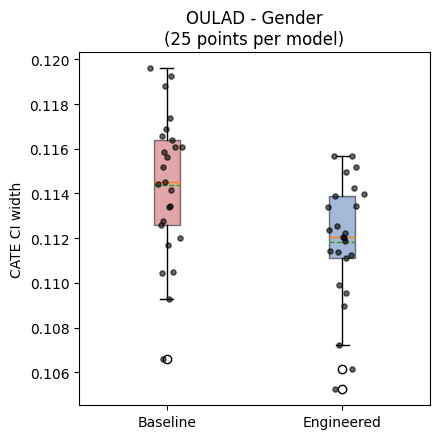

Wilcoxon signed-rank test on CI width: statistic=0.0000, p=0.000000
Cohen's d: -0.8718
95% bootstrap CI on mean CI-width difference: [-0.0032, -0.0020]

===== OULAD - Gender: held-out confirmation (data never used in search) =====
--- treatment 1 vs 0 ---
                        Baseline  Engineered
CI width                0.109453    0.106067
AUC-PR                  0.928786    0.928785
Macro F1                0.818966    0.816711
At-risk recall          0.816386    0.820163
Equal Opportunity diff -0.021013   -0.022580
Equalized Odds diff     0.060074    0.063455

Baseline confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.82255444 0.17744556]
 [0.18361418 0.81638582]]
Engineered confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.81377966 0.18622034]
 [0.1798373  0.8201627 ]]


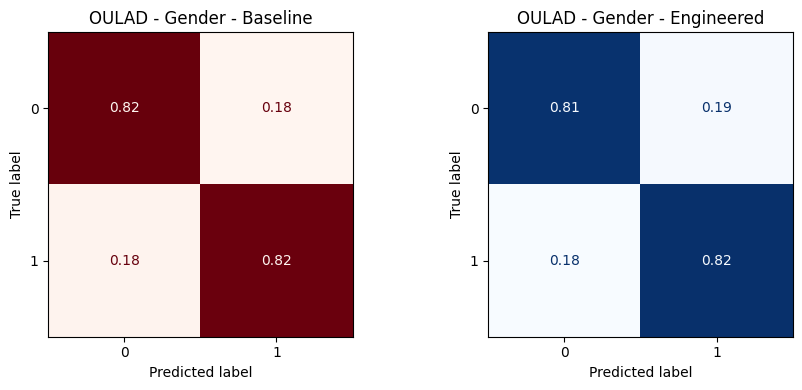

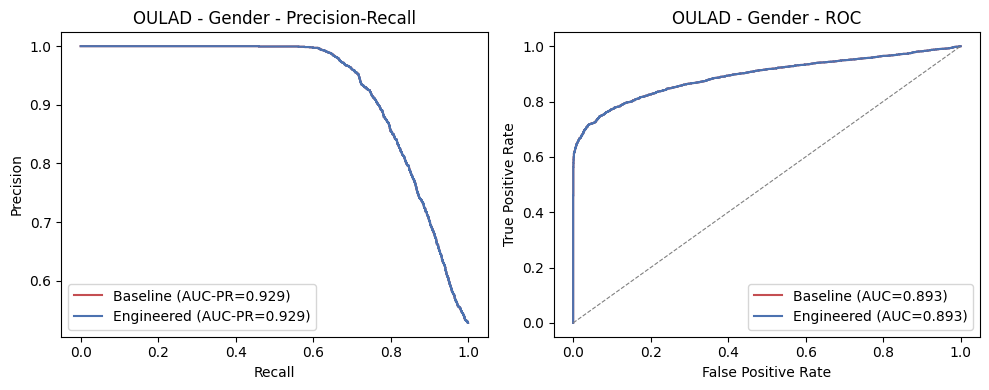

In [ ]:
# 4a. Gender: repeated CV + held-out confirmation + all plots
oulad_gender_baseline, oulad_gender_engineered, X_oulad_gender_confirm, Y_oulad_gender_confirm, T_oulad_gender_confirm = run_full_evaluation(
    X_oulad_raw, T_oulad_gender, Y_oulad, label="OULAD - Gender", n_repeats=5
)


===== OULAD - Location: repeated cross-validation (5 repeats x 5 folds) =====
--- treatment 1 vs 0 ---
                                  Baseline          Engineered
CI width                 0.0991 +/- 0.0025   0.0969 +/- 0.0025
AUC-PR                   0.9238 +/- 0.0032   0.9238 +/- 0.0032
Macro F1                 0.8051 +/- 0.0048   0.8031 +/- 0.0045
At-risk recall           0.8090 +/- 0.0084   0.8119 +/- 0.0083
Equal Opportunity diff  -0.0162 +/- 0.0134  -0.0170 +/- 0.0129
Equalized Odds diff      0.0255 +/- 0.0128   0.0249 +/- 0.0129

--- treatment 2 vs 0 ---
                                  Baseline          Engineered
CI width                 0.1069 +/- 0.0025   0.1041 +/- 0.0022
AUC-PR                   0.9238 +/- 0.0032   0.9238 +/- 0.0032
Macro F1                 0.8051 +/- 0.0048   0.8031 +/- 0.0045
At-risk recall           0.8090 +/- 0.0084   0.8119 +/- 0.0083
Equal Opportunity diff  -0.0567 +/- 0.0189  -0.0566 +/- 0.0179
Equalized Odds diff      0.0570 +/- 0.0185   0.0571 

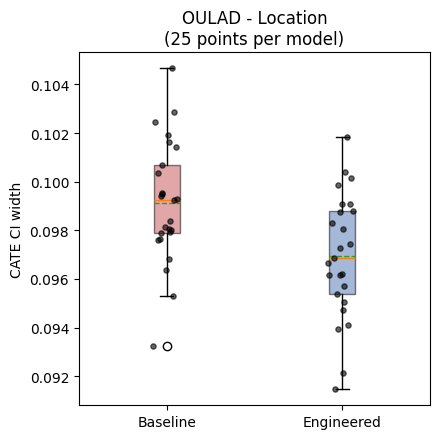

Wilcoxon signed-rank test on CI width: statistic=0.0000, p=0.000000
Cohen's d: -0.8778
95% bootstrap CI on mean CI-width difference: [-0.0027, -0.0017]

===== OULAD - Location: held-out confirmation (data never used in search) =====
--- treatment 1 vs 0 ---
                        Baseline  Engineered
CI width                0.090098    0.088661
AUC-PR                  0.928881    0.928882
Macro F1                0.820686    0.818780
At-risk recall          0.816095    0.818129
Equal Opportunity diff -0.021416   -0.025187
Equalized Odds diff     0.021416    0.025187

--- treatment 2 vs 0 ---
                        Baseline  Engineered
CI width                0.098593    0.096931
AUC-PR                  0.928881    0.928882
Macro F1                0.820686    0.818780
At-risk recall          0.816095    0.818129
Equal Opportunity diff -0.032863   -0.034039
Equalized Odds diff     0.032863    0.034039

Baseline confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.

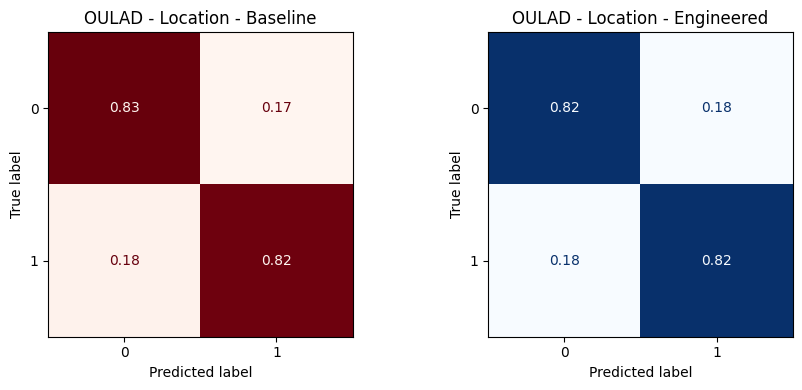

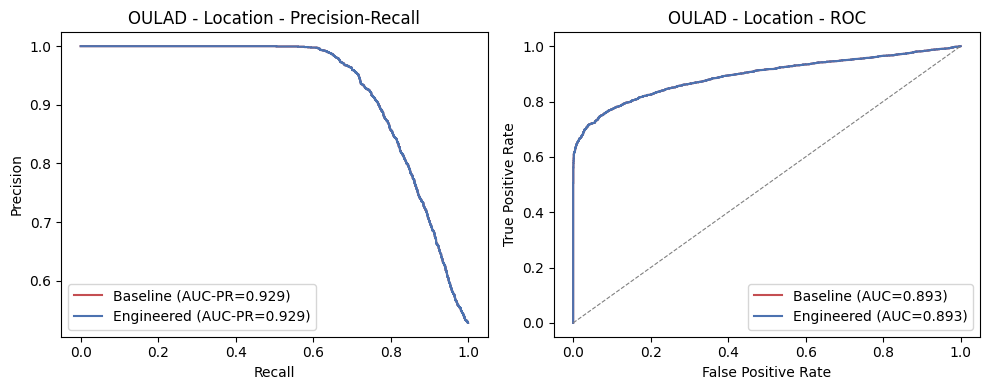

In [ ]:
# 4b. Location: repeated CV + held-out confirmation + all plots
oulad_loc_baseline, oulad_loc_engineered, X_oloc_confirm, Y_oloc_confirm, T_oloc_confirm = run_full_evaluation(
    X_oulad_raw, T_oulad_location, Y_oulad, label="OULAD - Location",
    comparisons=((0, 1), (0, 2)), n_repeats=5
)


## 5. GhEduData Data

In [20]:
# 5a. Load the anonymized GhEduData file
ghedudata = pd.read_excel("GhEduData_Merged_Anonymized.xlsx", sheet_name="GhEduData_Merged")
print("Students loaded:", len(ghedudata))


Students loaded: 995


In [21]:
# 5b. Clean checkbox artifacts left over from the original data collection form
def clean_text(value):
    value = str(value).replace("\u25a1", "").strip()
    return " ".join(value.split())

messy_columns = ["Governance_Type", "Location_Category", "Avg_Class_Size", "Pct_Teachers_Degree",
                  "Teacher_Student_Ratio", "Classroom_Condition", "English_Textbook_Access",
                  "Math_Textbook_Access", "Home_Study_Access", "Socioeconomic_Profile"]

for col in messy_columns:
    ghedudata[col] = ghedudata[col].apply(clean_text)


In [22]:
# 5c. Build the outcome and the three treatments
ghedudata["at_risk"] = (ghedudata["Aggregate"] >= 21).astype(int)
ghedudata["gender_num"] = ghedudata["Gender"].apply(lambda x: 1 if x == "Male" else 0)

def encode_location(value):
    levels = {"Rural": 0, "Peri-urban": 1, "Urban": 2}
    return levels.get(value, -1)

ghedudata["location_num"] = ghedudata["Location_Category"].apply(encode_location)
ghedudata["school_type_num"] = ghedudata["Governance_Type"].apply(lambda x: 1 if "Private" in x else 0)

print("At-risk count:", ghedudata["at_risk"].sum(), "out of", len(ghedudata))


At-risk count: 249 out of 995


In [23]:
# 5d. Build the student-level confounders (used for every treatment)
def encode_attendance(v):
    if "Less than 50%" in v: return 0
    if "50" in v and "74" in v: return 1
    if "75" in v and "90" in v: return 2
    if "More than 90%" in v: return 3
    return -1

def encode_homework(v):
    if "Rarely" in v: return 0
    if "Sometimes" in v: return 1
    if "Often" in v: return 2
    if "Almost always" in v: return 3
    return -1

def encode_participation(v):
    if "Passive" in v: return 0
    if "Very active" in v: return 3
    if "Moderate" in v: return 1
    if "Active" in v: return 2
    return -1

ghedudata["attendance_num"] = ghedudata["Attendance Rate"].apply(encode_attendance)
ghedudata["homework_num"] = ghedudata["Homework Submission Rate"].apply(encode_homework)
ghedudata["participation_num"] = ghedudata["Classroom Participation"].apply(encode_participation)

student_level_confounders = ["Age", "attendance_num", "homework_num", "participation_num"]


In [24]:
# 5e. Build the school-level confounders (used only for gender - see M7 in Methods)
def encode_class_size(v):
    sizes = {"Fewer than 20": 0, "20\u201335": 1, "36\u201350": 2,
             "51 - 65": 3, "66 - 80": 4, "More than 80": 5}
    return sizes.get(v, -1)

def encode_teacher_qual(v):
    quals = {"Less than 25%": 0, "50\u201375%": 1, "More than 75%": 2}
    return quals.get(v, -1)

def encode_teacher_ratio(v):
    if "fewer than 25" in v: return 0
    if "25\u201335" in v: return 1
    if "36\u201350" in v: return 2
    if "51 - 65" in v: return 3
    if "66 - 80" in v: return 4
    return -1

def encode_condition(v):
    if "Some classrooms are inadequate" in v: return 0
    if "Mostly adequate" in v: return 1
    if "All classrooms adequate" in v: return 2
    return -1

def encode_textbook(v):
    if "3 or more" in v: return 0
    if "between 2" in v: return 1
    if "own copy" in v: return 2
    return -1

def encode_home_study(v):
    if "Fewer than 25%" in v: return 0
    if "25\u201349%" in v: return 1
    if "More than 75%" in v: return 3
    if "50" in v: return 2
    return -1

def encode_socioeconomic(v):
    if "subsistence" in v: return 0
    if "middle income" in v: return 2
    if "high income" in v: return 3
    if "low income" in v: return 1
    return -1

ghedudata["class_size_num"] = ghedudata["Avg_Class_Size"].apply(encode_class_size)
ghedudata["teacher_qual_num"] = ghedudata["Pct_Teachers_Degree"].apply(encode_teacher_qual)
ghedudata["teacher_ratio_num"] = ghedudata["Teacher_Student_Ratio"].apply(encode_teacher_ratio)
ghedudata["classroom_condition_num"] = ghedudata["Classroom_Condition"].apply(encode_condition)
ghedudata["english_textbook_num"] = ghedudata["English_Textbook_Access"].apply(encode_textbook)
ghedudata["math_textbook_num"] = ghedudata["Math_Textbook_Access"].apply(encode_textbook)
ghedudata["home_study_num"] = ghedudata["Home_Study_Access"].apply(encode_home_study)
ghedudata["socioeconomic_num"] = ghedudata["Socioeconomic_Profile"].apply(encode_socioeconomic)

school_level_confounders = ["class_size_num", "teacher_qual_num", "teacher_ratio_num",
                             "classroom_condition_num", "english_textbook_num",
                             "math_textbook_num", "home_study_num", "socioeconomic_num"]

full_confounders = student_level_confounders + school_level_confounders

for col in ["attendance_num", "homework_num", "participation_num"] + school_level_confounders:
    unmatched = (ghedudata[col] == -1).sum()
    if unmatched > 0:
        print("WARNING - unmatched values in", col, ":", unmatched)
print("Encoding check complete.")


Encoding check complete.


In [25]:
# 5f. Build the final unscaled arrays and the school-type overlap trim
X_gh_full_raw = ghedudata[full_confounders].values
X_gh_student_raw = ghedudata[student_level_confounders].values

Y_gh = ghedudata["at_risk"].values
T_gh_gender = ghedudata["gender_num"].values
T_gh_location = ghedudata["location_num"].values
T_gh_schooltype = ghedudata["school_type_num"].values

overlap_check = LogisticRegression(max_iter=1000)
overlap_check.fit(X_gh_student_raw, T_gh_schooltype)
predicted_prob = overlap_check.predict_proba(X_gh_student_raw)[:, 1]
keep_mask = (predicted_prob >= 0.05) & (predicted_prob <= 0.95)

X_gh_schooltype_raw = X_gh_student_raw[keep_mask]
T_gh_schooltype_trimmed = T_gh_schooltype[keep_mask]
Y_gh_schooltype_trimmed = Y_gh[keep_mask]

print("Students kept for school type:", keep_mask.sum(), "out of", len(keep_mask))


Students kept for school type: 925 out of 995


## 6. GhEduData Results

===== GhEduData - Gender: repeated cross-validation (10 repeats x 5 folds) =====
--- treatment 1 vs 0 ---
                                  Baseline          Engineered
CI width                 0.2105 +/- 0.0160   0.1805 +/- 0.0152
AUC-PR                   0.7161 +/- 0.0770   0.7154 +/- 0.0772
Macro F1                 0.7755 +/- 0.0380   0.7916 +/- 0.0388
At-risk recall           0.6056 +/- 0.0800   0.7109 +/- 0.0694
Equal Opportunity diff  -0.0046 +/- 0.1487  -0.0070 +/- 0.1282
Equalized Odds diff      0.1209 +/- 0.0889   0.1082 +/- 0.0781

Mean training time per fit: baseline 1.839s +/- 0.342s | engineered 1.811s +/- 0.374s



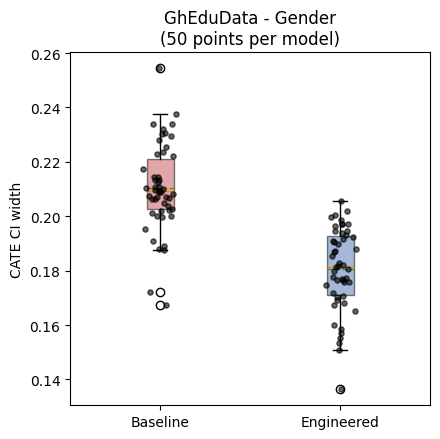

Wilcoxon signed-rank test on CI width: statistic=0.0000, p=0.000000
Cohen's d: -1.9223
95% bootstrap CI on mean CI-width difference: [-0.0324, -0.0274]

===== GhEduData - Gender: held-out confirmation (data never used in search) =====
--- treatment 1 vs 0 ---
                        Baseline  Engineered
CI width                0.223646    0.179073
AUC-PR                  0.657172    0.661961
Macro F1                0.723248    0.721859
At-risk recall          0.480000    0.620000
Equal Opportunity diff -0.253119   -0.219251
Equalized Odds diff     0.253119    0.219251

Baseline confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.9261745 0.0738255]
 [0.52      0.48     ]]
Engineered confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.83892617 0.16107383]
 [0.38       0.62      ]]


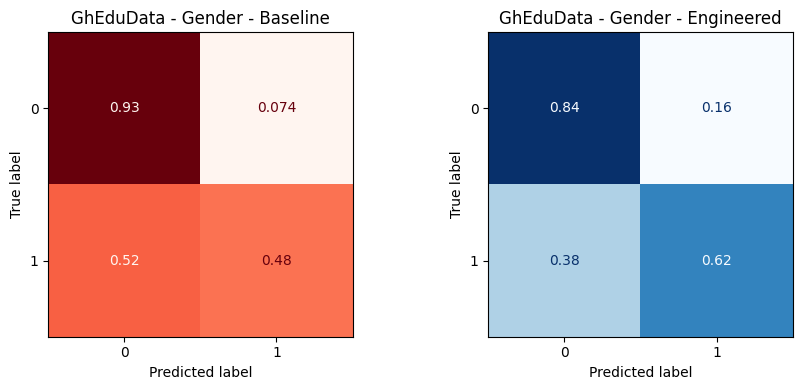

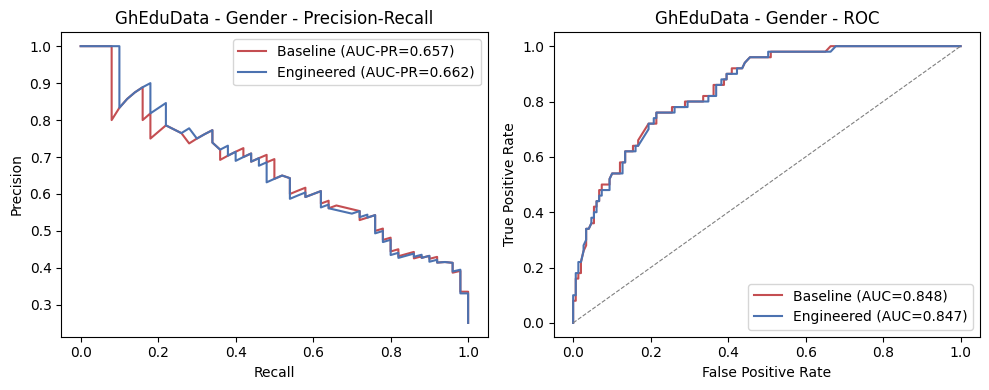

In [26]:
# 6a. Gender: repeated CV + held-out confirmation + all plots
gh_gender_baseline, gh_gender_engineered, X_gh_gender_confirm, Y_gh_gender_confirm, T_gh_gender_confirm = run_full_evaluation(
    X_gh_full_raw, T_gh_gender, Y_gh, label="GhEduData - Gender", n_repeats=10
)


===== GhEduData - Location: repeated cross-validation (10 repeats x 5 folds) =====
--- treatment 1 vs 0 ---
                                 Baseline         Engineered
CI width                0.3514 +/- 0.0252  0.3042 +/- 0.0258
AUC-PR                  0.5817 +/- 0.0695  0.5822 +/- 0.0699
Macro F1                0.6737 +/- 0.0481  0.6988 +/- 0.0405
At-risk recall          0.4178 +/- 0.0913  0.5713 +/- 0.0797
Equal Opportunity diff  0.0925 +/- 0.2436  0.1502 +/- 0.1930
Equalized Odds diff     0.2074 +/- 0.1602  0.2123 +/- 0.1294

--- treatment 2 vs 0 ---
                                 Baseline         Engineered
CI width                0.3593 +/- 0.0297  0.3093 +/- 0.0278
AUC-PR                  0.5817 +/- 0.0695  0.5822 +/- 0.0699
Macro F1                0.6737 +/- 0.0481  0.6988 +/- 0.0405
At-risk recall          0.4178 +/- 0.0913  0.5713 +/- 0.0797
Equal Opportunity diff  0.0487 +/- 0.3247  0.1193 +/- 0.3235
Equalized Odds diff     0.2685 +/- 0.1914  0.2848 +/- 0.1964

Mean traini

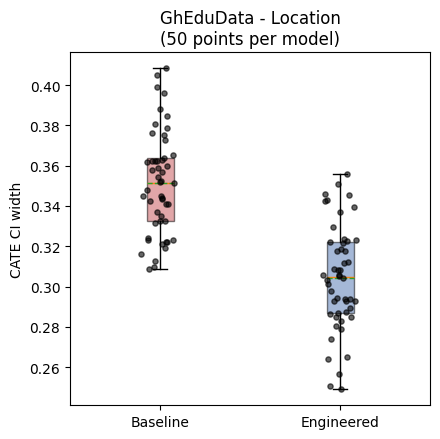

Wilcoxon signed-rank test on CI width: statistic=6.0000, p=0.000000
Cohen's d: -1.8535
95% bootstrap CI on mean CI-width difference: [-0.0524, -0.0414]

===== GhEduData - Location: held-out confirmation (data never used in search) =====
--- treatment 1 vs 0 ---
                        Baseline  Engineered
CI width                0.354915    0.303453
AUC-PR                  0.553361    0.555467
Macro F1                0.611819    0.679085
At-risk recall          0.320000    0.540000
Equal Opportunity diff -0.050676    0.040541
Equalized Odds diff     0.080597    0.091684

--- treatment 2 vs 0 ---
                        Baseline  Engineered
CI width                0.346079    0.304376
AUC-PR                  0.553361    0.555467
Macro F1                0.611819    0.679085
At-risk recall          0.320000    0.540000
Equal Opportunity diff -0.175000    0.100000
Equalized Odds diff     0.175000    0.221884

Baseline confusion matrix (normalized by true class, rows=true, cols=predicted):


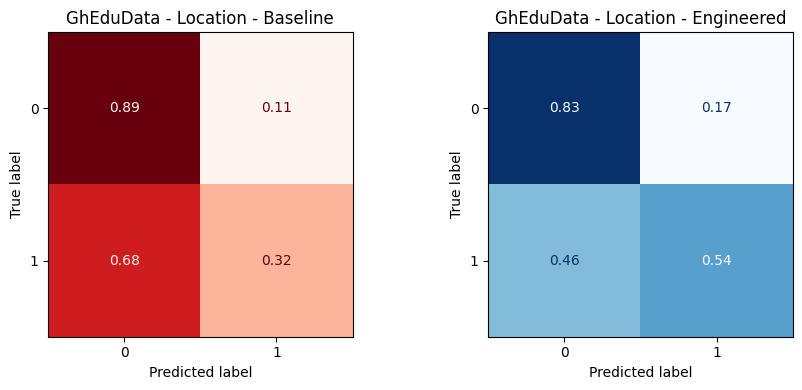

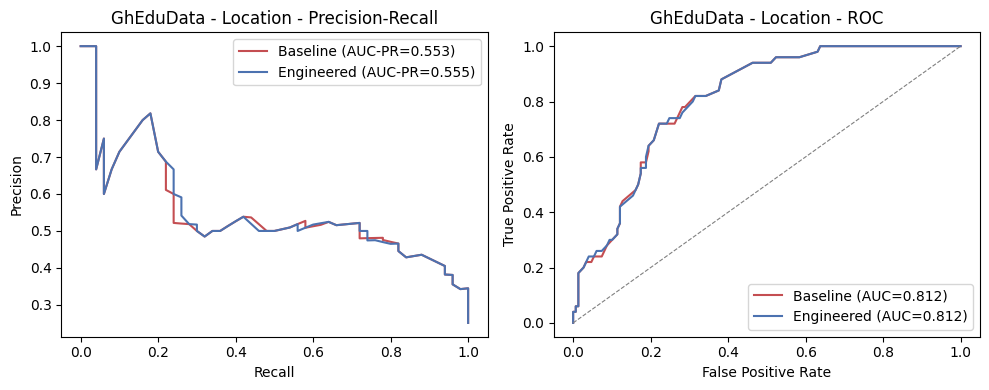

In [27]:
# 6b. Location: repeated CV + held-out confirmation + all plots
gh_loc_baseline, gh_loc_engineered, X_gh_loc_confirm, Y_gh_loc_confirm, T_gh_loc_confirm = run_full_evaluation(
    X_gh_student_raw, T_gh_location, Y_gh, label="GhEduData - Location",
    comparisons=((0, 1), (0, 2)), n_repeats=10
)


===== GhEduData - School Type: repeated cross-validation (10 repeats x 5 folds) =====
--- treatment 1 vs 0 ---
                                 Baseline         Engineered
CI width                0.3243 +/- 0.0328  0.2669 +/- 0.0228
AUC-PR                  0.4921 +/- 0.0644  0.4929 +/- 0.0644
Macro F1                0.6025 +/- 0.0491  0.6506 +/- 0.0377
At-risk recall          0.2635 +/- 0.0890  0.4708 +/- 0.0803
Equal Opportunity diff        nan +/- nan        nan +/- nan
Equalized Odds diff           nan +/- nan        nan +/- nan

Mean training time per fit: baseline 1.610s +/- 0.201s | engineered 1.587s +/- 0.233s



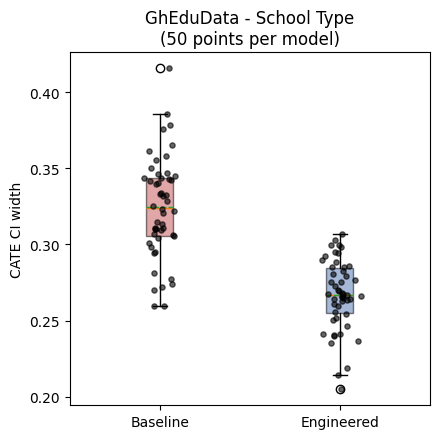

Wilcoxon signed-rank test on CI width: statistic=0.0000, p=0.000000
Cohen's d: -2.0321
95% bootstrap CI on mean CI-width difference: [-0.0626, -0.0524]

===== GhEduData - School Type: held-out confirmation (data never used in search) =====
--- treatment 1 vs 0 ---
                        Baseline  Engineered
CI width                0.314380    0.258935
AUC-PR                  0.589959    0.590508
Macro F1                0.621247    0.750533
At-risk recall          0.250000    0.600000
Equal Opportunity diff -0.270270   -0.288288
Equalized Odds diff     0.270270    0.288288

Baseline confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.95862069 0.04137931]
 [0.75       0.25      ]]
Engineered confusion matrix (normalized by true class, rows=true, cols=predicted):
[[0.89655172 0.10344828]
 [0.4        0.6       ]]


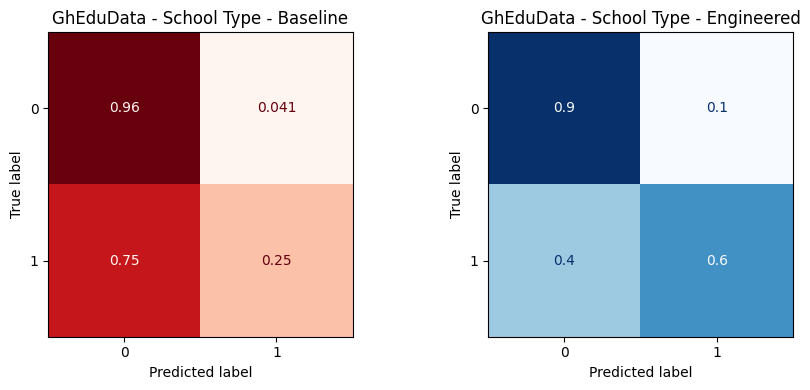

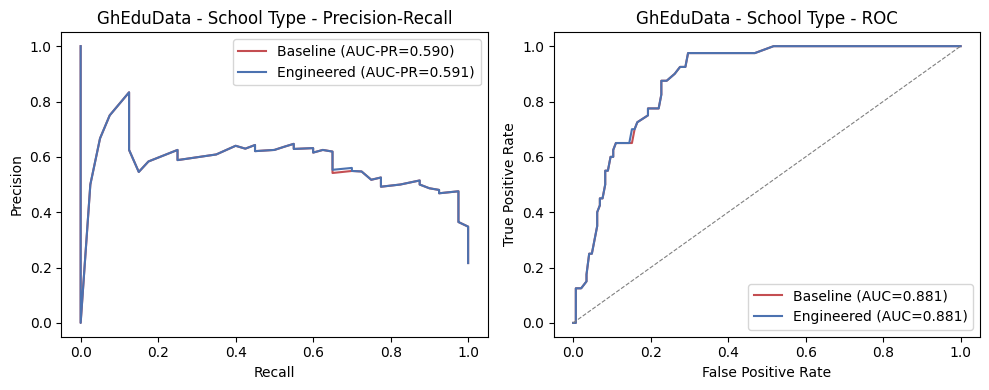

In [28]:
# 6c. School type: repeated CV + held-out confirmation + all plots (trimmed, overlap-safe data)
gh_school_baseline, gh_school_engineered, X_gh_school_confirm, Y_gh_school_confirm, T_gh_school_confirm = run_full_evaluation(
    X_gh_schooltype_raw, T_gh_schooltype_trimmed, Y_gh_schooltype_trimmed,
    label="GhEduData - School Type", n_repeats=10
)


## 7. Ablation Isolation

In [29]:
# 7a. Isolate each engineered component separately, on GhEduData Gender
# (baseline, leaf-only, weight-only, full) - required for the ablation table
search_idx, confirm_idx = train_test_split(
    np.arange(len(Y_gh)), test_size=0.2, random_state=42, stratify=Y_gh
)
X_search_raw = X_gh_full_raw[search_idx]
T_search = T_gh_gender[search_idx]
Y_search = Y_gh[search_idx]

ablation_results = {c: {k: [] for k in METRIC_KEYS} for c in ["baseline", "leaf_only", "weight_only", "full"]}

for repeat in range(10):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=repeat)
    for tr_idx, te_idx in skf.split(X_search_raw, Y_search):
        X_tr, X_te, T_tr, T_te, Y_tr, Y_te, qw = prepare_fold(X_search_raw, T_search, Y_search, tr_idx, te_idx)

        m_baseline = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=5)
        m_leaf_only = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=8)
        m_weight_only = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=5, class_weight=qw)
        m_full = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=8, class_weight=qw)

        for name, model in [("baseline", m_baseline), ("leaf_only", m_leaf_only),
                             ("weight_only", m_weight_only), ("full", m_full)]:
            scores = evaluate_model(model, X_te, Y_te, T_te)
            for k in METRIC_KEYS:
                ablation_results[name][k].append(scores[k])

print("=== Ablation isolation: GhEduData - Gender (10 repeats x 5 folds) ===")
table = {}
for name in ["baseline", "leaf_only", "weight_only", "full"]:
    table[name] = [f"{np.mean(ablation_results[name][k]):.4f} +/- {np.std(ablation_results[name][k]):.4f}"
                   for k in METRIC_KEYS]
ablation_table = pd.DataFrame(table, index=METRIC_KEYS)
print(ablation_table)


=== Ablation isolation: GhEduData - Gender (10 repeats x 5 folds) ===
                                  baseline           leaf_only  \
CI width                 0.2103 +/- 0.0164   0.1793 +/- 0.0153   
AUC-PR                   0.7161 +/- 0.0770   0.7161 +/- 0.0770   
Macro F1                 0.7755 +/- 0.0380   0.7755 +/- 0.0380   
At-risk recall           0.6056 +/- 0.0800   0.6056 +/- 0.0800   
Equal Opportunity diff  -0.0046 +/- 0.1487  -0.0046 +/- 0.1487   
Equalized Odds diff      0.1209 +/- 0.0889   0.1209 +/- 0.0889   

                               weight_only                full  
CI width                 0.2135 +/- 0.0165   0.1815 +/- 0.0148  
AUC-PR                   0.7154 +/- 0.0772   0.7154 +/- 0.0772  
Macro F1                 0.7916 +/- 0.0388   0.7916 +/- 0.0388  
At-risk recall           0.7109 +/- 0.0694   0.7109 +/- 0.0694  
Equal Opportunity diff  -0.0070 +/- 0.1282  -0.0070 +/- 0.1282  
Equalized Odds diff      0.1082 +/- 0.0781   0.1082 +/- 0.0781  


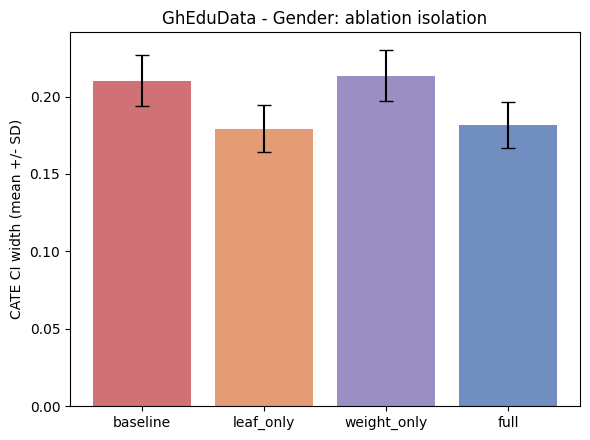

In [30]:
# 7b. Plot the ablation comparison for the primary metric (CI width)
fig, ax = plt.subplots(figsize=(6, 4.5))
conditions = ["baseline", "leaf_only", "weight_only", "full"]
means = [np.mean(ablation_results[c]["CI width"]) for c in conditions]
sds = [np.std(ablation_results[c]["CI width"]) for c in conditions]
colors = ["#c44e52", "#dd8452", "#8172b3", "#4c72b0"]

ax.bar(conditions, means, yerr=sds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel("CATE CI width (mean +/- SD)")
ax.set_title("GhEduData - Gender: ablation isolation")
plt.tight_layout()
plt.savefig("ablation_ci_width_barplot.png", dpi=300)
plt.show()


In [31]:
# 7c. Export raw per-fold CI width values and raw predicted probabilities
raw_fold_records = []
for repeat in range(10):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=repeat)
    fold_num = 0
    for tr_idx, te_idx in skf.split(X_search_raw, Y_search):
        fold_num += 1
        X_tr, X_te, T_tr, T_te, Y_tr, Y_te, qw = prepare_fold(X_search_raw, T_search, Y_search, tr_idx, te_idx)

        base_model = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=5)
        eng_model = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=8, class_weight=qw)

        b_lo, b_hi = base_model.effect_interval(X_te, alpha=0.05)
        e_lo, e_hi = eng_model.effect_interval(X_te, alpha=0.05)

        raw_fold_records.append({
            "repeat": repeat, "fold": fold_num,
            "baseline_ci_width": (b_hi - b_lo).mean(),
            "engineered_ci_width": (e_hi - e_lo).mean(),
        })

raw_fold_df = pd.DataFrame(raw_fold_records)
raw_fold_df.to_csv("gender_fold_level_ci_width.csv", index=False)
print(raw_fold_df.describe())


          repeat       fold  baseline_ci_width  engineered_ci_width
count  50.000000  50.000000          50.000000            50.000000
mean    4.500000   3.000000           0.210967             0.179721
std     2.901442   1.428571           0.016588             0.015392
min     0.000000   1.000000           0.170694             0.139783
25%     2.000000   2.000000           0.202179             0.169502
50%     4.500000   3.000000           0.210092             0.181459
75%     7.000000   4.000000           0.222133             0.190460
max     9.000000   5.000000           0.255921             0.210592


In [32]:
# 7d. Export raw predicted probabilities on the held-out confirmation set
X_tr, X_te, T_tr, T_te, Y_tr, Y_te, qw_confirm = prepare_fold(
    X_gh_full_raw, T_gh_gender, Y_gh, search_idx, confirm_idx
)
confirm_baseline = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=5)
confirm_engineered = fit_causal_forest(X_tr, T_tr, Y_tr, min_samples_leaf=8, class_weight=qw_confirm)

probs_df = pd.DataFrame({
    "y_true": Y_te,
    "baseline_prob": confirm_baseline.models_y[0][0].predict_proba(X_te)[:, 1],
    "engineered_prob": confirm_engineered.models_y[0][0].predict_proba(X_te)[:, 1],
})
probs_df.to_csv("gender_confirmation_probabilities.csv", index=False)
print(probs_df.describe())


           y_true  baseline_prob  engineered_prob
count  199.000000     199.000000       199.000000
mean     0.251256       0.246613         0.294760
std      0.434830       0.268195         0.294012
min      0.000000       0.003454         0.004657
25%      0.000000       0.028068         0.038493
50%      0.000000       0.124266         0.177069
75%      0.500000       0.421770         0.521958
max      1.000000       0.965524         0.977347


## 8. SHAP Equity Diagnostics

In [33]:
# 8a. Function: compute, report and plot SHAP values for one fitted model
def run_shap_diagnostics(model, X_confirm, feature_names, label):
    shap_dict = model.shap_values(X_confirm, feature_names=feature_names)
    outcome_key = list(shap_dict.keys())[0]
    treatment_key = list(shap_dict[outcome_key].keys())[0]
    explanation = shap_dict[outcome_key][treatment_key]

    mean_abs_shap = np.abs(explanation.values).mean(axis=0)
    ranking = sorted(zip(explanation.feature_names, mean_abs_shap), key=lambda x: -x[1])

    print(f"=== SHAP ranking: {label} ===")
    for name, value in ranking:
        print(f"{name}: {value:.4f}")
    print()

    fig, ax = plt.subplots(figsize=(6, max(2.5, 0.35 * len(ranking))))
    names = [r[0] for r in ranking][::-1]
    values = [r[1] for r in ranking][::-1]
    ax.barh(names, values, color="#4c72b0")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(label)
    plt.tight_layout()
    safe_name = label.replace(" ", "_").replace("-", "").replace("/", "_")
    plt.savefig(f"shap_ranking_{safe_name}.png", dpi=300)
    plt.show()

    return explanation


=== SHAP ranking: GhEduData - Gender ===
home_study_num: 0.0123
homework_num: 0.0116
teacher_ratio_num: 0.0065
attendance_num: 0.0063
Age: 0.0049
participation_num: 0.0047
socioeconomic_num: 0.0038
classroom_condition_num: 0.0031
class_size_num: 0.0028
english_textbook_num: 0.0020
math_textbook_num: 0.0016
teacher_qual_num: 0.0005



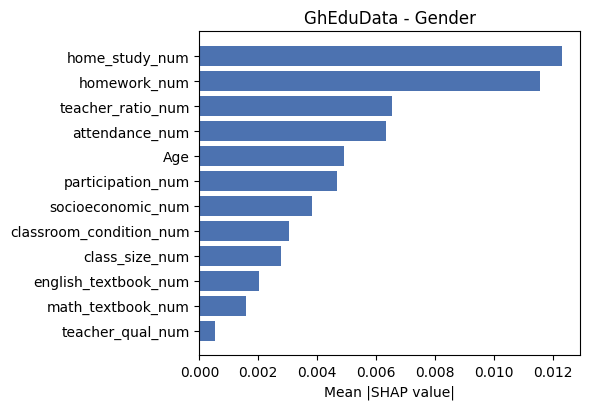

In [34]:
# 8b. GhEduData - Gender
gh_gender_shap = run_shap_diagnostics(
    gh_gender_engineered, X_gh_gender_confirm, full_confounders, label="GhEduData - Gender"
)


=== SHAP ranking: GhEduData - Location ===
attendance_num: 0.0893
participation_num: 0.0321
homework_num: 0.0212
Age: 0.0063



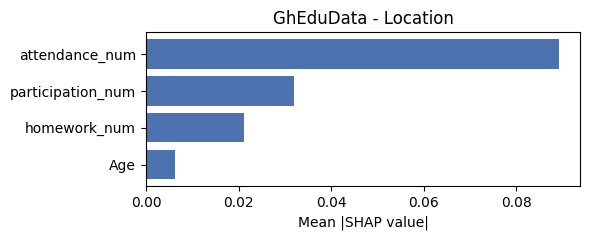

In [35]:
# 8c. GhEduData - Location
gh_loc_shap = run_shap_diagnostics(
    gh_loc_engineered, X_gh_loc_confirm, student_level_confounders, label="GhEduData - Location"
)


=== SHAP ranking: GhEduData - School Type ===
Age: 0.0422
homework_num: 0.0400
participation_num: 0.0254
attendance_num: 0.0244



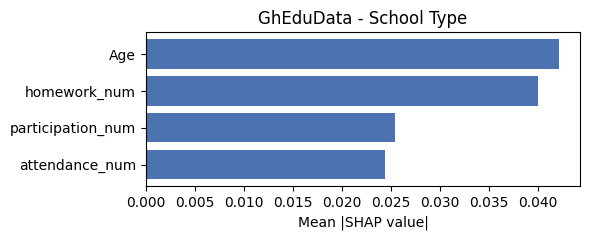

In [36]:
# 8d. GhEduData - School Type
gh_school_shap = run_shap_diagnostics(
    gh_school_engineered, X_gh_school_confirm, student_level_confounders, label="GhEduData - School Type"
)


100%|===================| 6505/6519 [05:29<00:00]       

=== SHAP ranking: OULAD - Gender ===
submitted_count: 0.0566
total_clicks: 0.0161
active_days: 0.0161
education_num: 0.0020
age_num: 0.0018



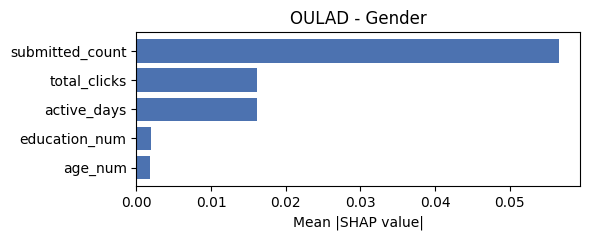

In [37]:
# 8e. OULAD - Gender
_search_idx, _confirm_idx = train_test_split(
    np.arange(len(Y_oulad)), test_size=0.2, random_state=42, stratify=Y_oulad
)
_, X_oulad_gender_confirm, _, T_oulad_gender_confirm, _, Y_oulad_gender_confirm, _ = prepare_fold(
    X_oulad_raw, T_oulad_gender, Y_oulad, _search_idx, _confirm_idx
)

oulad_gender_shap = run_shap_diagnostics(
    oulad_gender_engineered, X_oulad_gender_confirm, oulad_confounders, label="OULAD - Gender"
)


100%|===================| 13022/13038 [10:26<00:00]       

=== SHAP ranking: OULAD - Location ===
active_days: 0.0153
submitted_count: 0.0151
total_clicks: 0.0060
education_num: 0.0019
age_num: 0.0007



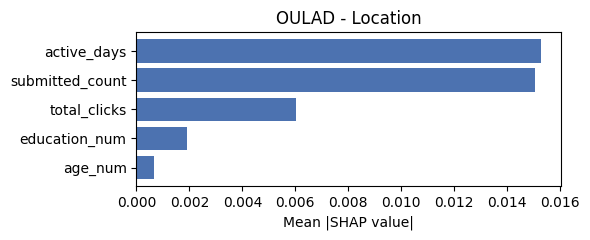

In [38]:
# 8f. OULAD - Location
oulad_loc_shap = run_shap_diagnostics(
    oulad_loc_engineered, X_oloc_confirm, oulad_confounders, label="OULAD - Location"
)
